In [37]:
import random
import torch
import numpy as np
def setup_seed(seed: int = 42, deterministic: bool = False):

    random.seed(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
    
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.enabled = False  
        
seed = 3407
setup_seed(seed=seed)

Loading data...


/tmp/ipykernel_2310/358782216.py:10: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  adata = sc.read_h5ad('GSE222378_SCCRISPR-full-object.h5ad')


                            orig.ident  nCount_RNA  nFeature_RNA batch  \
exp1-TP1_AAACCCAGTATCCCTC-1   SCCRISPR     25191.0          4591  exp1   
exp1-TP1_AAACGAACAGGCCCTA-1   SCCRISPR     24236.0          4760  exp1   
exp1-TP1_AAACGAATCTCGGTCT-1   SCCRISPR      2190.0          1107  exp1   
exp1-TP1_AAACGCTCAAGGGCAT-1   SCCRISPR     14769.0          3784  exp1   
exp1-TP1_AAACGCTCATCGATAC-1   SCCRISPR     56108.0          6619  exp1   

                            timepoint   CRISPRguide CRISPRgene        BT  \
exp1-TP1_AAACCCAGTATCCCTC-1       TP1  Stat5b_gRNA5     Stat5b  exp1-TP1   
exp1-TP1_AAACGAACAGGCCCTA-1       TP1  Notch1_gRNA1     Notch1  exp1-TP1   
exp1-TP1_AAACGAATCTCGGTCT-1       TP1     Fos_gRNA4        Fos  exp1-TP1   
exp1-TP1_AAACGCTCAAGGGCAT-1       TP1     Jun_gRNA1        Jun  exp1-TP1   
exp1-TP1_AAACGCTCATCGATAC-1       TP1   Hoxa1_gRNA4      Hoxa1  exp1-TP1   

                             percent.mito   S.Score  G2M.Score Phase  \
exp1-TP1_AAACCCAGTATCCCTC-

/tmp/ipykernel_2310/358782216.py:45: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(adata, basis=basis, color='CRISPRgene', title='Colored by CRISPR Gene', save='raw_data_CRISPRgene_labeled')


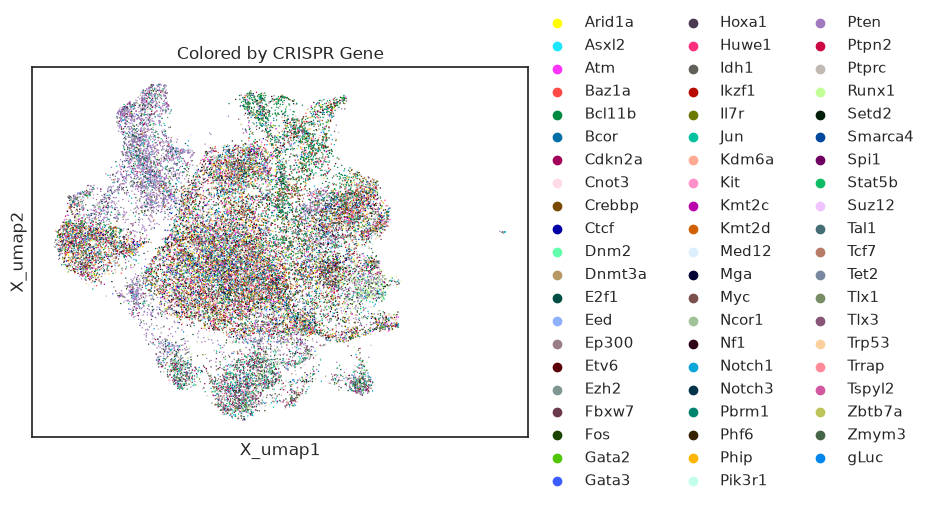

/tmp/ipykernel_2310/358782216.py:49: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(adata, basis=basis, color='timepoint', title='Colored by Timepoint', save='raw_data_timepoint_labeled')


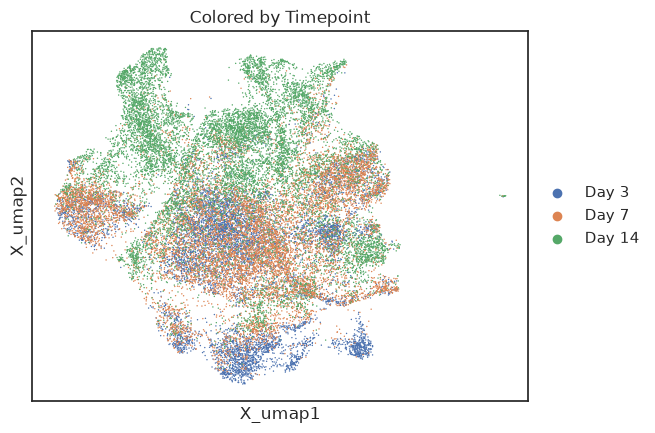

/tmp/ipykernel_2310/358782216.py:53: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(adata, basis=basis, color='batch', title='Colored by Batch', save='raw_data_batch_labeled')


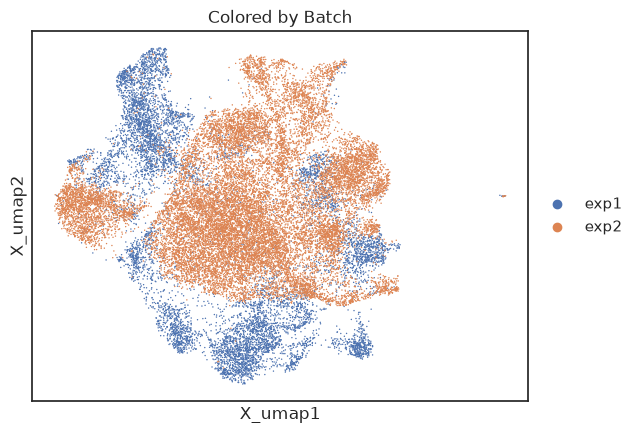

/tmp/ipykernel_2310/358782216.py:55: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(adata, basis=basis, color='Phase', title='Colored by Cell Cycle Phase', save='raw_data_Phase_labeled')


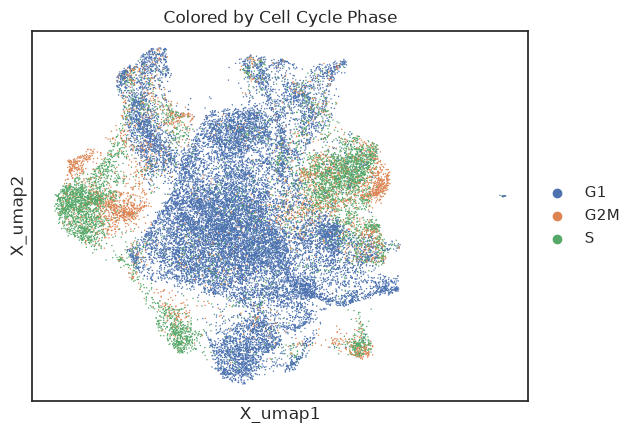

/tmp/ipykernel_2310/358782216.py:57: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(adata, basis=basis, color='seurat_clusters', title='Colored by Clusters', save='raw_data_seurat_clusters_labeled')


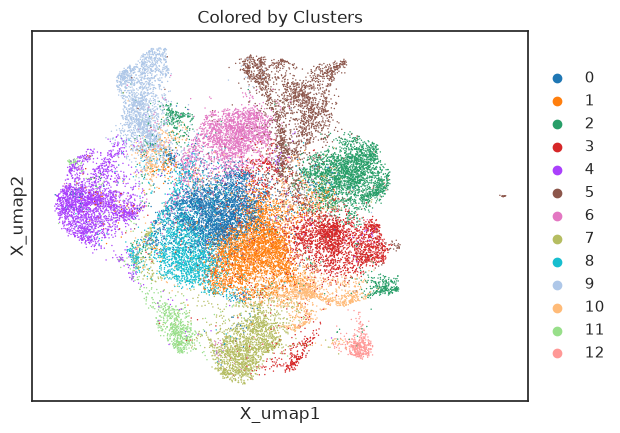

In [38]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap

# --- 1. 加载数据 ---
print("Loading data...") 

adata = sc.read_h5ad('GSE222378_SCCRISPR-full-object.h5ad')

print(adata.obs.head(5))
print(adata.var)
print(adata.X)


adata.obs['seurat_clusters'] = adata.obs['seurat_clusters'].astype('category')


from sklearn.decomposition import PCA

pca_model = PCA(n_components=50, random_state=42)


pca_embedding = pca_model.fit_transform(adata.X)

adata.obsm['X_pca'] = pca_embedding


reducer = umap.UMAP(n_neighbors=10, min_dist=0.3, n_components=2, n_jobs=1, random_state=seed)


data_contiguous = np.ascontiguousarray(adata.obsm['X_pca'])
data_contiguous = data_contiguous.astype(np.float32)
embedding = reducer.fit_transform(data_contiguous)

adata.obsm['X_umap'] = embedding


basis = 'X_umap'
point_dic = {'TP1':'Day 3','TP2':'Day 7','TP3':'Day 14'}
point_dic_inverse = {'Day 3':'TP1','Day 7':'TP2','Day 14':'TP3'}


sc.pl.embedding(adata, basis=basis, color='CRISPRgene', title='Colored by CRISPR Gene', save='raw_data_CRISPRgene_labeled')

adata.obs['timepoint'] = adata.obs['timepoint'].apply(lambda x: point_dic[x])

sc.pl.embedding(adata, basis=basis, color='timepoint', title='Colored by Timepoint', save='raw_data_timepoint_labeled')
adata.obs['timepoint'] = adata.obs['timepoint'].apply(lambda x: point_dic_inverse[x])


sc.pl.embedding(adata, basis=basis, color='batch', title='Colored by Batch', save='raw_data_batch_labeled')

sc.pl.embedding(adata, basis=basis, color='Phase', title='Colored by Cell Cycle Phase', save='raw_data_Phase_labeled')

sc.pl.embedding(adata, basis=basis, color='seurat_clusters', title='Colored by Clusters', save='raw_data_seurat_clusters_labeled')


In [39]:
import torch
import scope
from scope import model
from scope import computations as cmp
from scope import clustering as cl
from scope import pre_match as pm
from scope import visualizations as vi

data_lst = [torch.Tensor(adata[adata.obs[adata.obs['timepoint']==t].index,:].obsm['X_pca']).double() for t in adata.obs['timepoint'].unique()]
time_steps = [3,7,14]
meta=[[time_steps[i]]*len(data_lst[i]) for i in range(len(time_steps))]
meta=np.concatenate(meta)

In [40]:
cluster_centers, labels_list, best_k = cl.kmeans_auto([d.cuda() for d in data_lst],tol=1e-4,method='calinski_harabasz',max_k=10,least_Ks=5)
print(best_k)

max_variance_differences = cmp.max_adjacent_covariance_diagonal_differences(data_lst)
print(max_variance_differences)
eps_func = cmp.piecewise_eps_function(time_steps, max_variance_differences,snr=0.99,min_eps=0.5) 

[5, 5, 5]
[24.714207936401962, 325.88285088227383]


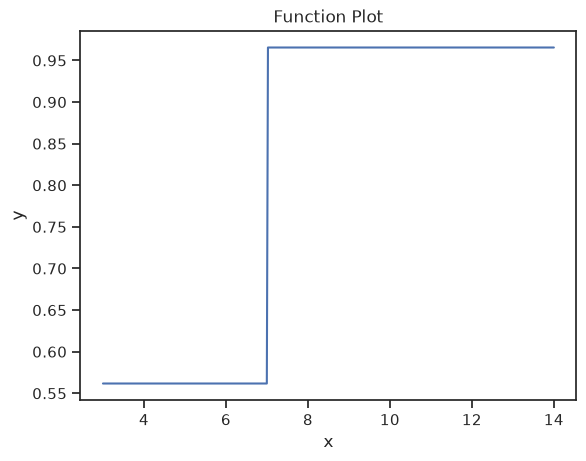

In [41]:
x = np.linspace(time_steps[0], time_steps[-1], 400)

y = [eps_func(x_i) for x_i in x]

plt.plot(x, y)

plt.title('Function Plot')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

INFO: Preparing data for visualization...
INFO: UMAP model provided. Transforming high-dimensional data to 2D...


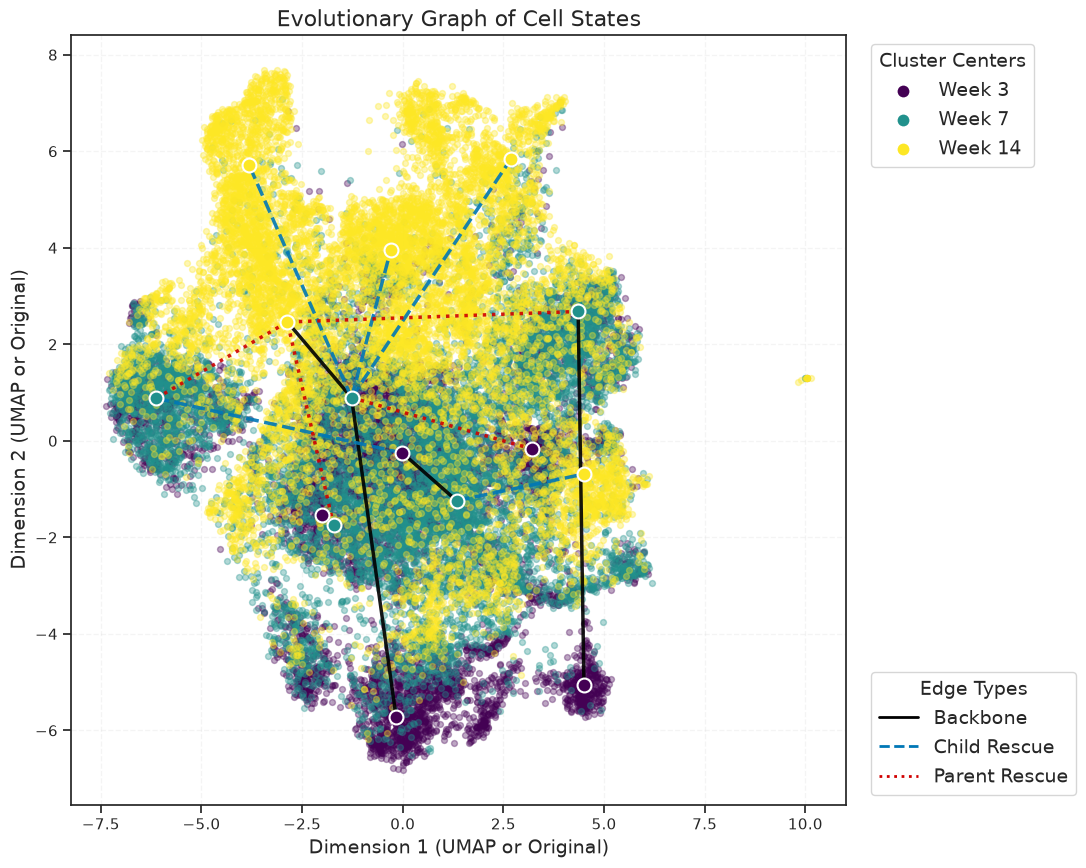

In [42]:
all_points_map, msf_edges = pm.calculate_evolutionary_graph([c.cpu().numpy() for c in cluster_centers], metric='euclidean')
vi.visualize_full_evolution(
    raw_data=[d.cpu().numpy() for d in data_lst],
    centers=[c.cpu().numpy() for c in cluster_centers],
    all_points_map=all_points_map,
    edges=msf_edges,
    umap_model=reducer,
    time_labels=['Week ' + str(t) for t in time_steps]
)

Re-indexing nodes to continuous integers...
Graph simplification and re-indexing complete.
INFO: Preparing data for visualization...
INFO: UMAP model provided. Transforming high-dimensional data to 2D...


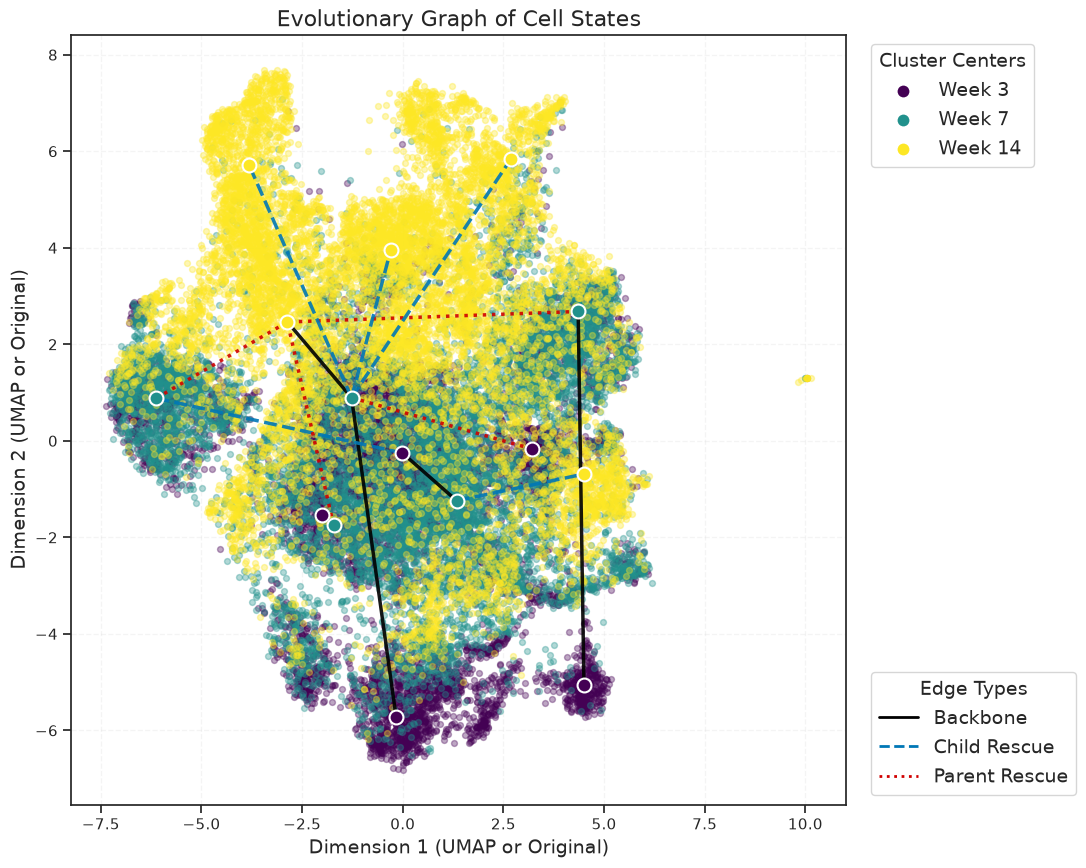

In [43]:
label_list_for_train = [cl.assign_labels(d.cuda(),cluster_centers[i].cuda()) for i, d in enumerate(data_lst)]
populations_map = cmp.count_cluster_samples(label_list_for_train)

all_points_map, cluster_centers, msf_edges = pm.simplify_evolutionary_graph(all_points_map, populations_map, msf_edges, epsilon_merge=10, theta_topo=0.5, metric='euclidean')
vi.visualize_full_evolution(
    raw_data=[d.cpu().numpy() for d in data_lst],
    centers=cluster_centers,
    all_points_map=all_points_map,
    edges=msf_edges,
    umap_model=reducer,
    time_labels=['Week ' + str(t) for t in time_steps]
)
cluster_centers = [torch.from_numpy(c) for c in cluster_centers]

In [44]:
xu = reducer.transform(torch.concat(data_lst).numpy())

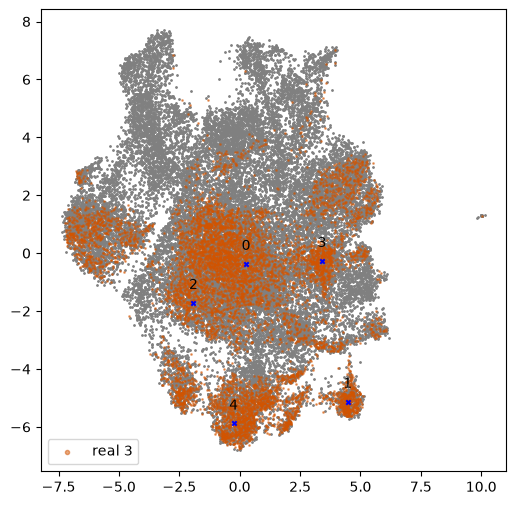

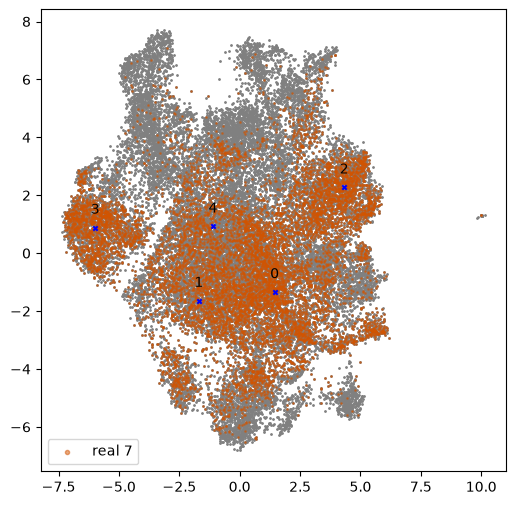

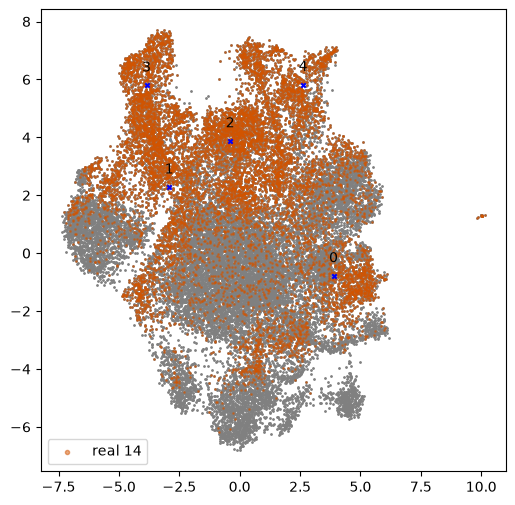

In [9]:
vi.visualize_populations(data_lst,time_steps,cluster_centers,umap_model=reducer,save_path='./CRISPR_results/raw_data')

In [45]:
import scope.datasets as ds

label_list_for_train = [cl.assign_labels(d.cuda(),cluster_centers[i].cuda()) for i, d in enumerate(data_lst)]

In [46]:
steps_each_day = 8
steps = 11*steps_each_day
# eps = lambda t: np.exp(0.1 * t) 
eps = eps_func
eps_test = eps
sb_object=model.sb_muti_model(data_lst,time_steps,N_pretraining=200,N_finetuning=200,backbone_lr=1e-3,finetuning_lr=1e-3,hiden_size=128,n_layers=4,
                              steps=steps,eps=eps,early_stop=True,patience=32,B=128,lambda_=0,save=True,record_gap=2,save_path='model_history/GSE222378',
                              prematched=True, label_list=label_list_for_train, edges=msf_edges, weighting_strategy='enos', beta=0.999)

INFO: 从演化图中找到了 12 条长度为 3 的有效路径（演化蓝图）。
defaultdict(<class 'float'>, {1: 0.3947863725043354, 3: 0.1474800211673589, 4: 0.11145701985741277, 2: 0.17912476189518178, 0: 0.16715182457571112})


In [12]:
#sb_object.backbone_train()
sb_object.backbone_load('/mnt/SCOPE_CODE/model_history/GSE222378/backbone.pt')
fore_base=sb_object.eval_fore(data_lst[0].cuda().double(),sb_object.v_fore)

/mnt/SCOPE_CODE/scope/model.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict=torch.load(model_path)


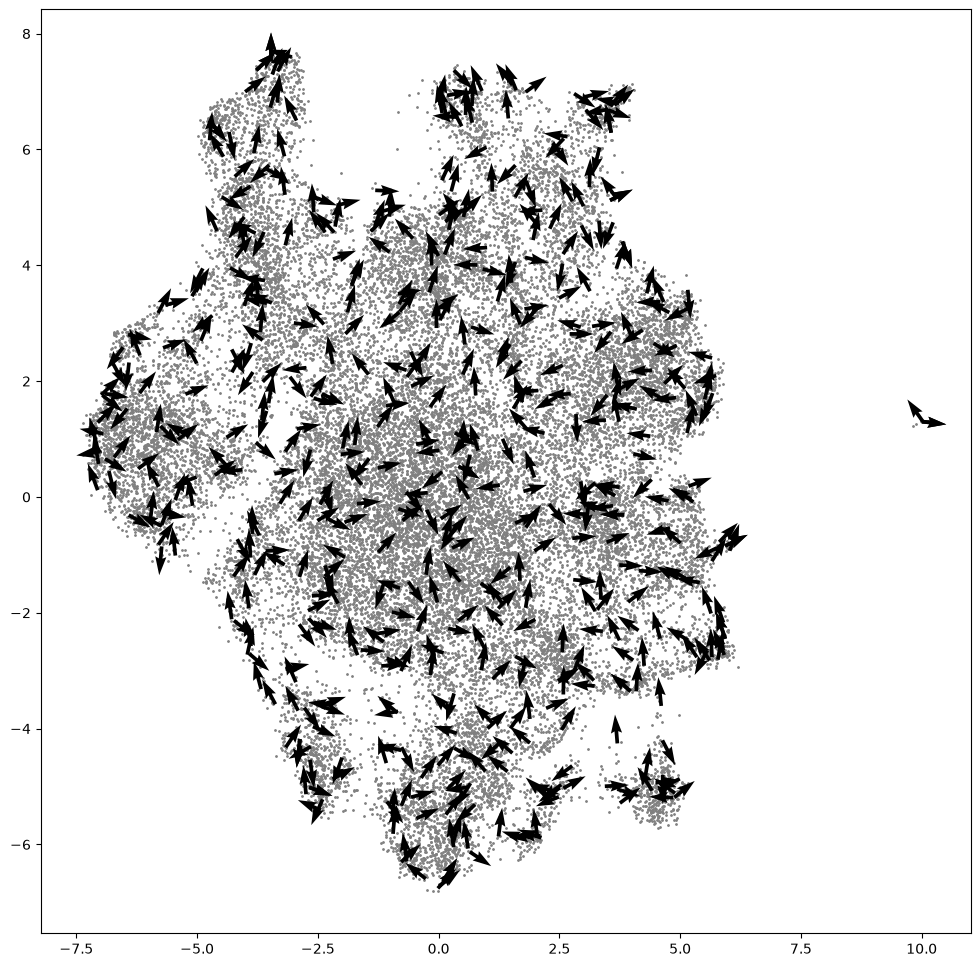

In [13]:
vi.visualize_drift_func([d.cuda() for d in data_lst],np.concatenate(data_lst),sb_object,meta,umap_model=reducer,save_path='./CRISPR_results/drift_backbone',xg_lower_bound=-10,xg_upper_bound=15,yg_lower_bound=-10,yg_upper_bound=10)

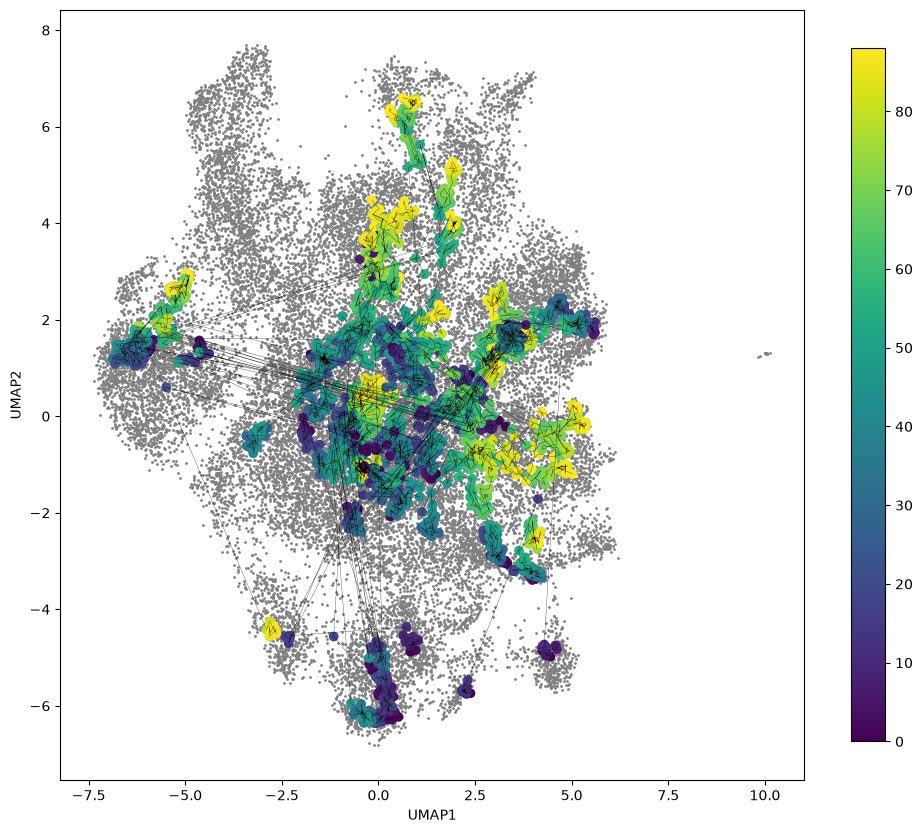

In [14]:
vi.visualize_generated_trajectories(data_lst,fore_base,umap_model=reducer,save_path='./CRISPR_results/generated_trajectories_backbone')

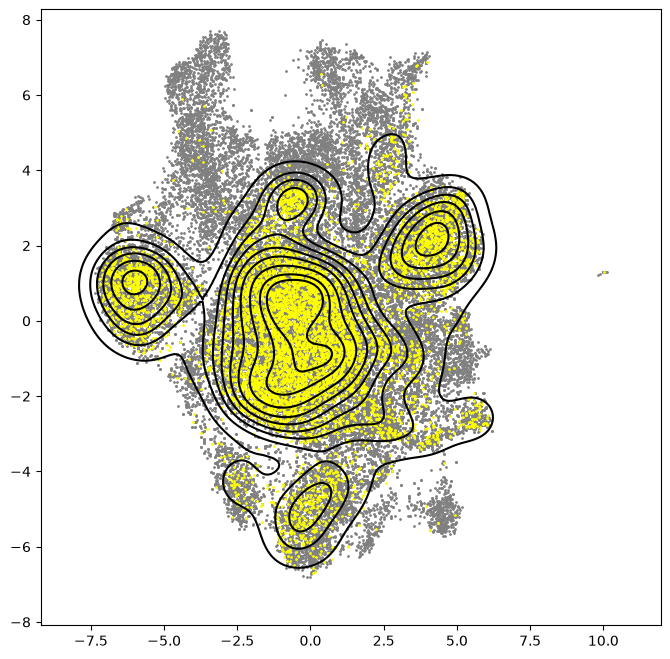

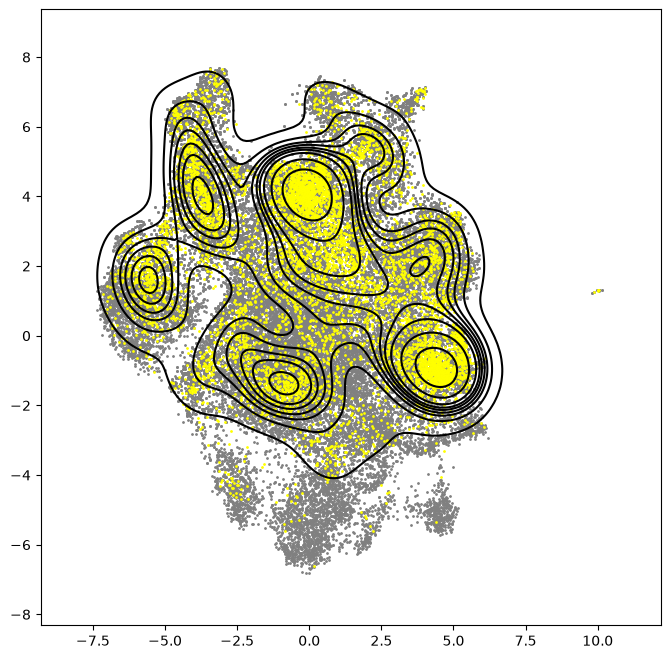

In [15]:
vi.visualize_generated_populations(data_lst,fore_base,time_steps,umap_model=reducer,save_path='./CRISPR_results/generated_populations_backbone')

In [15]:
#sb_object.fine_tune(change=25)

/mnt/SCOPE_CODE/scope/model.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict=torch.load(model_path)


In [47]:
sb_object.finetuning_load('/mnt/SCOPE_CODE/model_history/GSE222378/fine_tuned.pt')
fore_ft=sb_object.eval_fore(data_lst[0].double(),sb_object.v_fore_fine_tuned)

/mnt/SCOPE_CODE/scope/model.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict=torch.load(model_path)


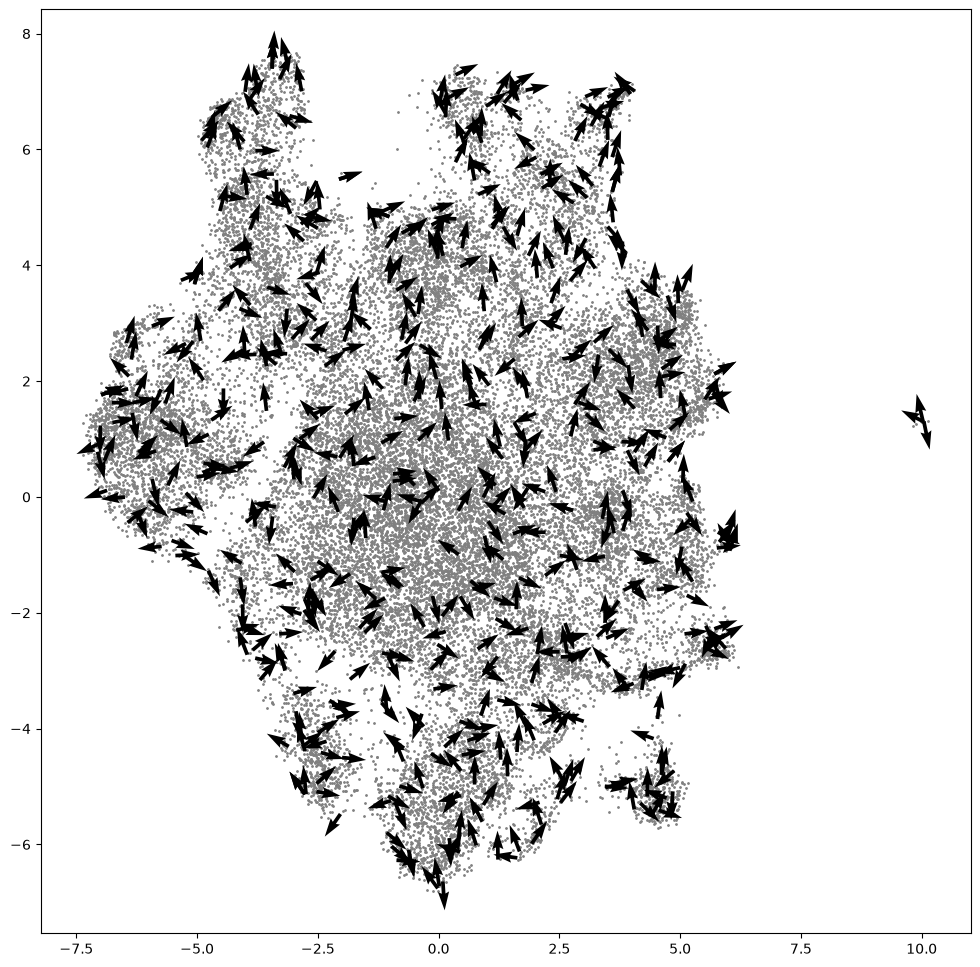

In [20]:
vi.visualize_drift_func(data_lst,np.concatenate(data_lst),sb_object,meta,umap_model=reducer,save_path='./CRISPR_results/drift_fine_tuned',fine_tuned=True,xg_lower_bound=-10,xg_upper_bound=15,yg_lower_bound=-10,yg_upper_bound=10)

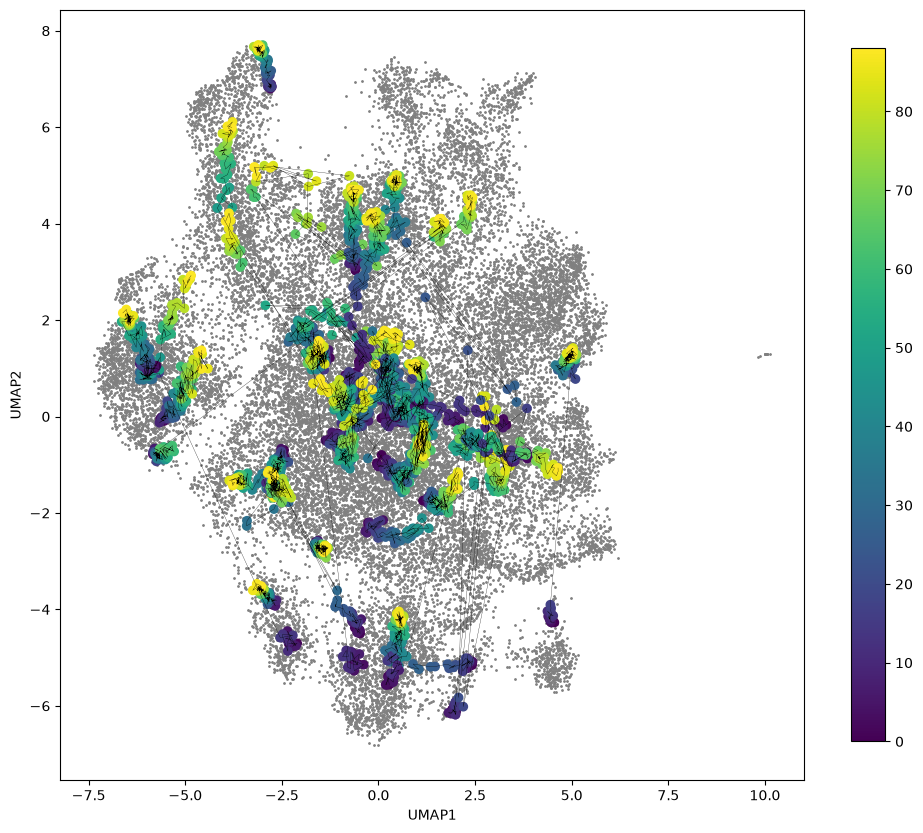

In [33]:
vi.visualize_generated_trajectories(data_lst,fore_ft,umap_model=reducer,save_path='./CRISPR_results/generated_trajectories_fine_tuned')

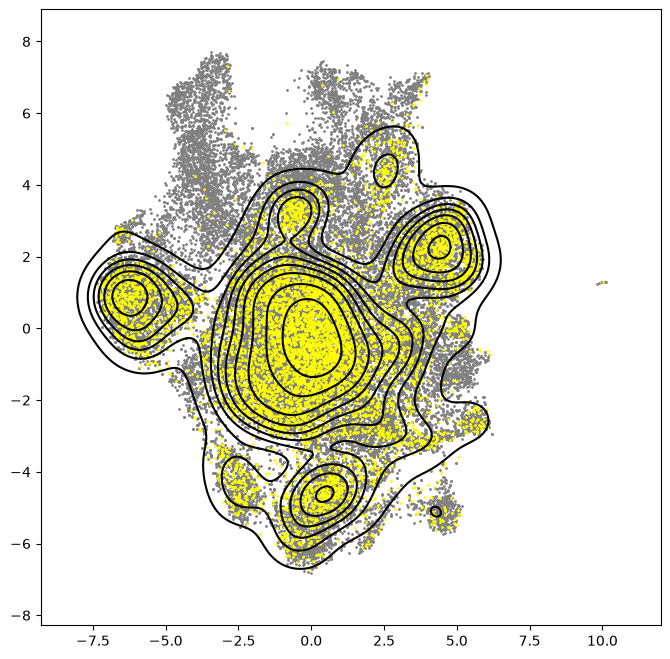

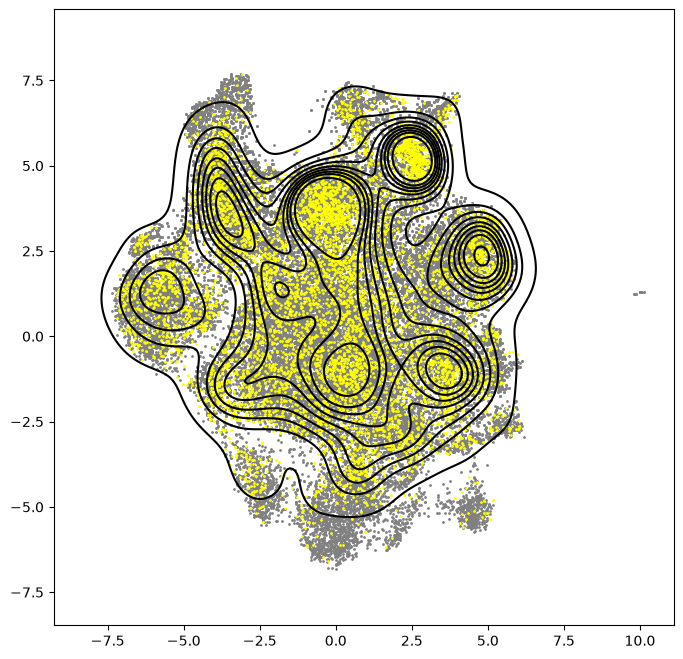

In [32]:
vi.visualize_generated_populations(data_lst,fore_ft,time_steps,umap_model=reducer,save_path='./CRISPR_results/generated_populations_fine_tuned')

In [62]:
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from typing import List, Dict, Tuple, Any, Optional, Union
def visualize_observed_populations(
    raw_data: List[torch.Tensor],
    observed_time_points: List[float],
    umap_model: Optional[Any] = None,
    adjust_equal: Optional[bool] = False,
    save_path: Optional[str] = None,
    adjust_upside_down: Optional[bool] = False,
    adjust_left_right: Optional[bool] = False,
):
    # 所有 observed data，作为灰色背景
    x_seq = torch.cat(raw_data).cpu().numpy()

    xu = (
        umap_model.transform(x_seq)
        if umap_model is not None
        else x_seq
    )

    for t in range(len(raw_data)):
        fig, ax = plt.subplots(figsize=(8, 8))

        # 当前时间点的 observed data
        raw_t = raw_data[t].cpu().numpy()

        xu_t = (
            umap_model.transform(raw_t)
            if umap_model is not None
            else raw_t
        )

        # 所有时间点的数据：灰色背景点
        ax.scatter(
            xu[:, 0] if not adjust_left_right else -xu[:, 0],
            xu[:, 1] if not adjust_upside_down else -xu[:, 1] + 9,
            s=1,
            color="gray"
        )

        # 当前 raw_data[t]：黄色点，画在灰色点上面
        ax.scatter(
            xu_t[:, 0] if not adjust_left_right else -xu_t[:, 0],
            xu_t[:, 1] if not adjust_upside_down else -xu_t[:, 1] + 9,
            s=1,
            color="yellow",
            label="Observed " + str(observed_time_points[t])
        )

        # 当前 raw_data[t] 的 KDE
        sns.kdeplot(
            x=xu_t[:, 0] if not adjust_left_right else -xu_t[:, 0],
            y=xu_t[:, 1] if not adjust_upside_down else -xu_t[:, 1] + 9,
            color="k",
            ax=ax
        )

        if adjust_equal:
            ax.set_aspect(
                "equal",
                adjustable="box"
            )

        if save_path is not None:
            plt.savefig(
                save_path + str(observed_time_points[t]) + ".svg",
                format="svg",
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.1
            )

        plt.show()

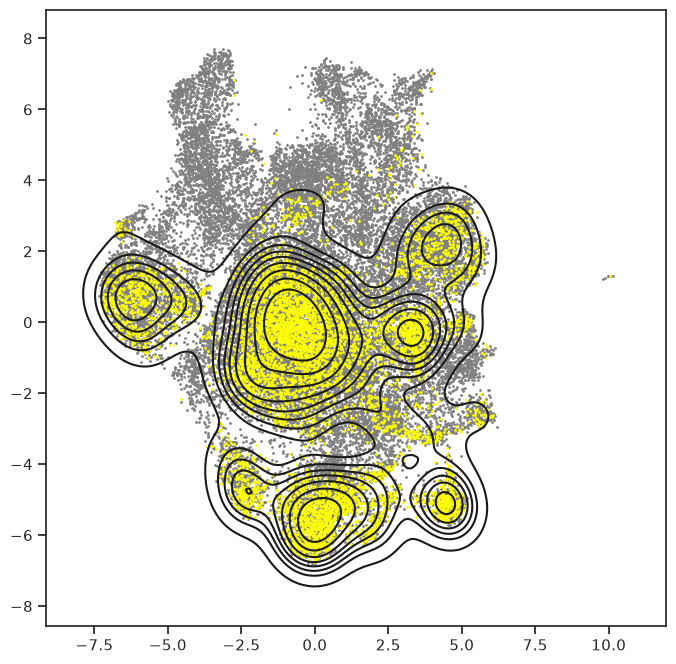

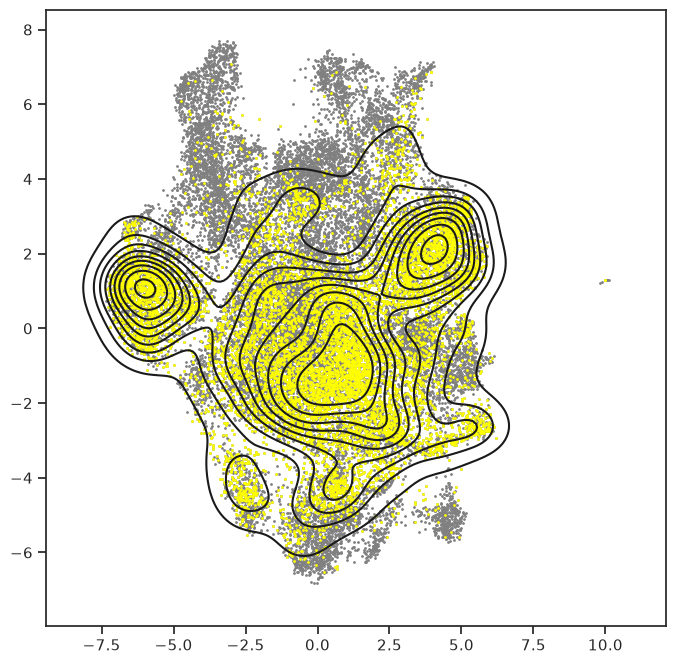

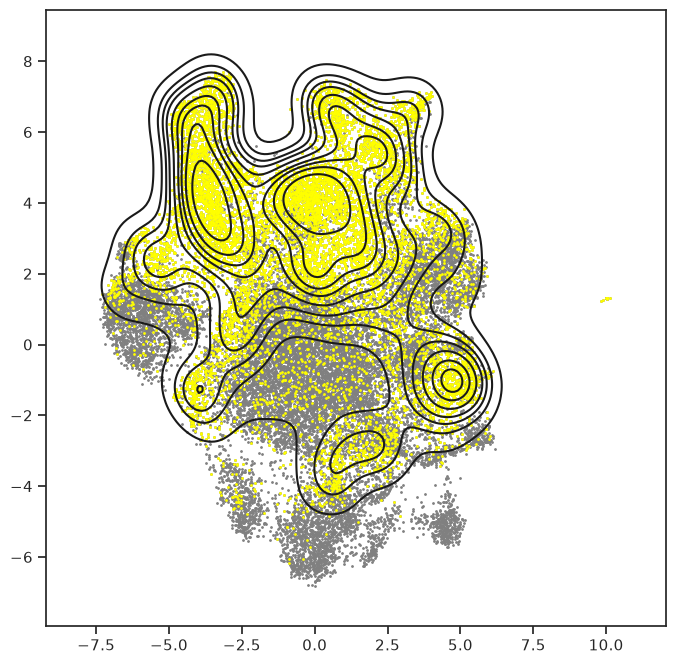

In [63]:
visualize_observed_populations(data_lst,time_steps,umap_model=reducer,save_path='./CRISPR_results/true_populations_fine_tuned')

In [53]:
import pandas as pd
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- a. 定义分析参数 ---
conditions_to_analyze = ['gLuc', 'Bcl11b', 'Spi1']
genes_for_plotting = ['Bcl11b', 'Stat1', 'Nfkb1', 'Myc', 'Ets1']
existing_genes = [g for g in genes_for_plotting if g in adata.var_names]
num_runs = 1000
print(f"--- 分析方案: 比较 {conditions_to_analyze} 作为起点的细胞演化路径 ---")

# --- b. 为每种细胞类型独立进行批量模拟 ---
predicted_paths = {}

def run_simulation_batch(start_expression_matrix, pca_model, sb_object):
    # (此函数与之前完全相同，为了简洁此处省略其内部代码)
    start_pca_batch = pca_model.transform(start_expression_matrix)
    path_pca_list = sb_object.eval_fore(torch.from_numpy(start_pca_batch).double(), sb_object.v_fore_fine_tuned)
    path_pca_tensor = np.stack(path_pca_list, axis=0)
    n_steps, n_runs, n_components = path_pca_tensor.shape
    path_pca_reshaped = path_pca_tensor.reshape(-1, n_components)
    path_gene_space_reshaped = pca_model.inverse_transform(path_pca_reshaped)
    path_gene_space_tensor = path_gene_space_reshaped.reshape(n_steps, n_runs, -1)
    return path_gene_space_tensor

for condition in conditions_to_analyze:
    print(f"\n--- 正在为 '{condition}' 起点细胞进行模拟 ---")
    possible_start_cells = adata[(adata.obs['CRISPRgene'] == condition) & (adata.obs['timepoint'] == 'TP1'), :]
    if len(possible_start_cells) == 0: continue
    current_runs = min(num_runs, len(possible_start_cells))
    random_indices = np.random.choice(possible_start_cells.obs.index, size=current_runs, replace=False)
    start_cells_expression = adata[random_indices, :].X.toarray()
    predicted_paths[condition] = run_simulation_batch(start_cells_expression, pca_model, sb_object)

print("\n--- 所有模拟完成 ---")

--- 分析方案: 比较 ['gLuc', 'Bcl11b', 'Spi1'] 作为起点的细胞演化路径 ---

--- 正在为 'gLuc' 起点细胞进行模拟 ---

--- 正在为 'Bcl11b' 起点细胞进行模拟 ---

--- 正在为 'Spi1' 起点细胞进行模拟 ---

--- 所有模拟完成 ---


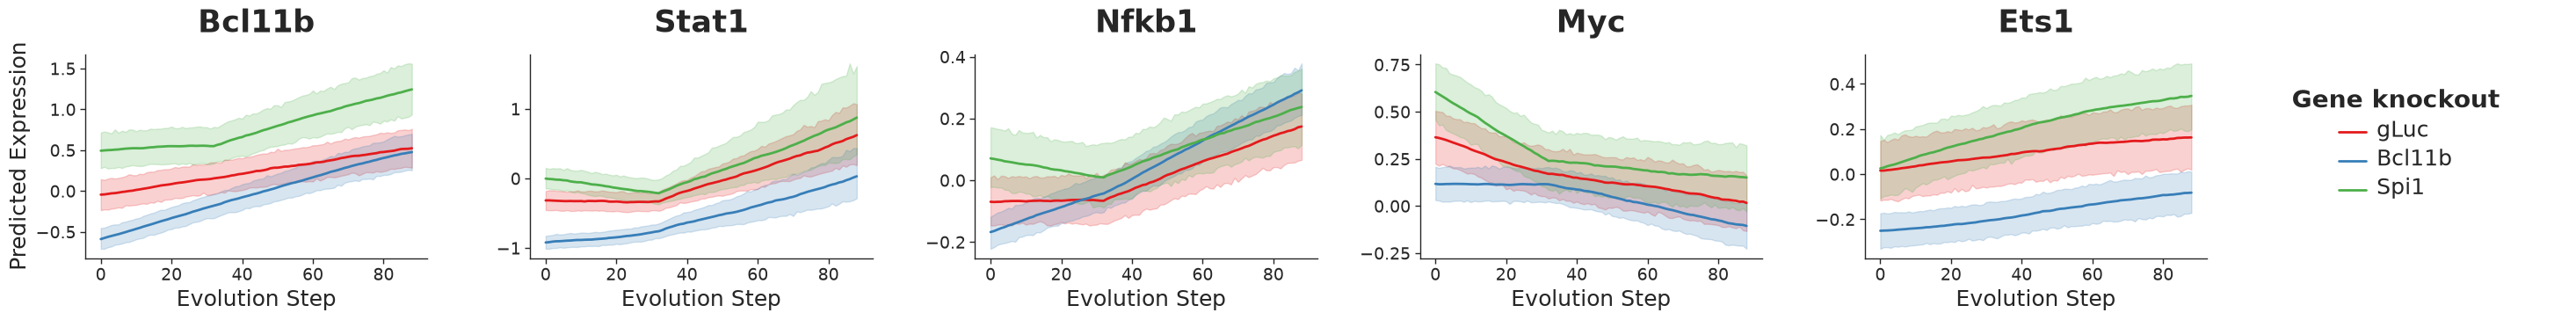

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator


# =========================================================
# 1. Prepare predicted trajectory data
# =========================================================
all_predicted_data = []

n_steps = list(predicted_paths.values())[0].shape[0]

gene_indices = [
    adata.var_names.get_loc(g)
    for g in existing_genes
]

for condition, tensor in predicted_paths.items():
    current_runs = tensor.shape[1]

    path_genes = (
        tensor[:, :, gene_indices]
        .reshape(-1, len(existing_genes))
    )

    df = pd.DataFrame(
        path_genes,
        columns=existing_genes
    )

    df["Evolution Step"] = np.repeat(
        np.arange(n_steps),
        current_runs
    )

    df["Starting Condition"] = condition

    all_predicted_data.append(df)


predicted_df = pd.concat(
    all_predicted_data,
    ignore_index=True
)

predicted_long_df = pd.melt(
    predicted_df,
    id_vars=[
        "Evolution Step",
        "Starting Condition"
    ],
    value_vars=existing_genes,
    var_name="Gene",
    value_name="Predicted Expression"
)


# =========================================================
# 2. Plot settings
# =========================================================
sns.set_theme(
    style="ticks",
    context="notebook"
)


g1 = sns.relplot(
    data=predicted_long_df,
    x="Evolution Step",
    y="Predicted Expression",
    hue="Starting Condition",
    col="Gene",
    kind="line",
    col_wrap=5,
    palette="Set1",
    height=4,
    aspect=1.2,
    linewidth=2,
    facet_kws={
        "sharey": False
    }
)


# =========================================================
# 3. Titles and axis labels
# =========================================================
g1.set_titles(
    col_template="{col_name}"
)

g1.set_axis_labels(
    "Evolution Step",
    "Predicted Expression"
)


for ax in g1.axes.flat:

    # Subplot title
    ax.set_title(
        ax.get_title(),
        fontsize=25,
        fontweight="bold",
        pad=18
    )

    # Remove background grid
    ax.grid(False)

    # Keep left and bottom axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    # Tick style
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14,
        width=1.0,
        length=4
    )

    # Axis-label font size
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)


# =========================================================
# 4. Move legend outside
# =========================================================
if g1._legend is not None:

    g1._legend.set_title(
        "Gene knockout"
    )

    plt.setp(
        g1._legend.get_title(),
        fontsize=20,
        fontweight="bold"
    )

    plt.setp(
        g1._legend.get_texts(),
        fontsize=18
    )

    # Place legend outside on the right
    g1._legend.set_bbox_to_anchor(
        (1.01, 0.5)
    )

    # Compatible with older matplotlib versions
    g1._legend._loc = 6

    g1._legend.set_frame_on(False)


# =========================================================
# 5. Figure spacing
# =========================================================
g1.fig.subplots_adjust(
    left=0.01,
    right=0.95,
    top=0.78,
    bottom=0.20,
    wspace=0.30
)


# =========================================================
# 6. Save
# =========================================================
plt.savefig(
    "./CRISPR_results/Predicted_Trajectories.svg",
    format="svg",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

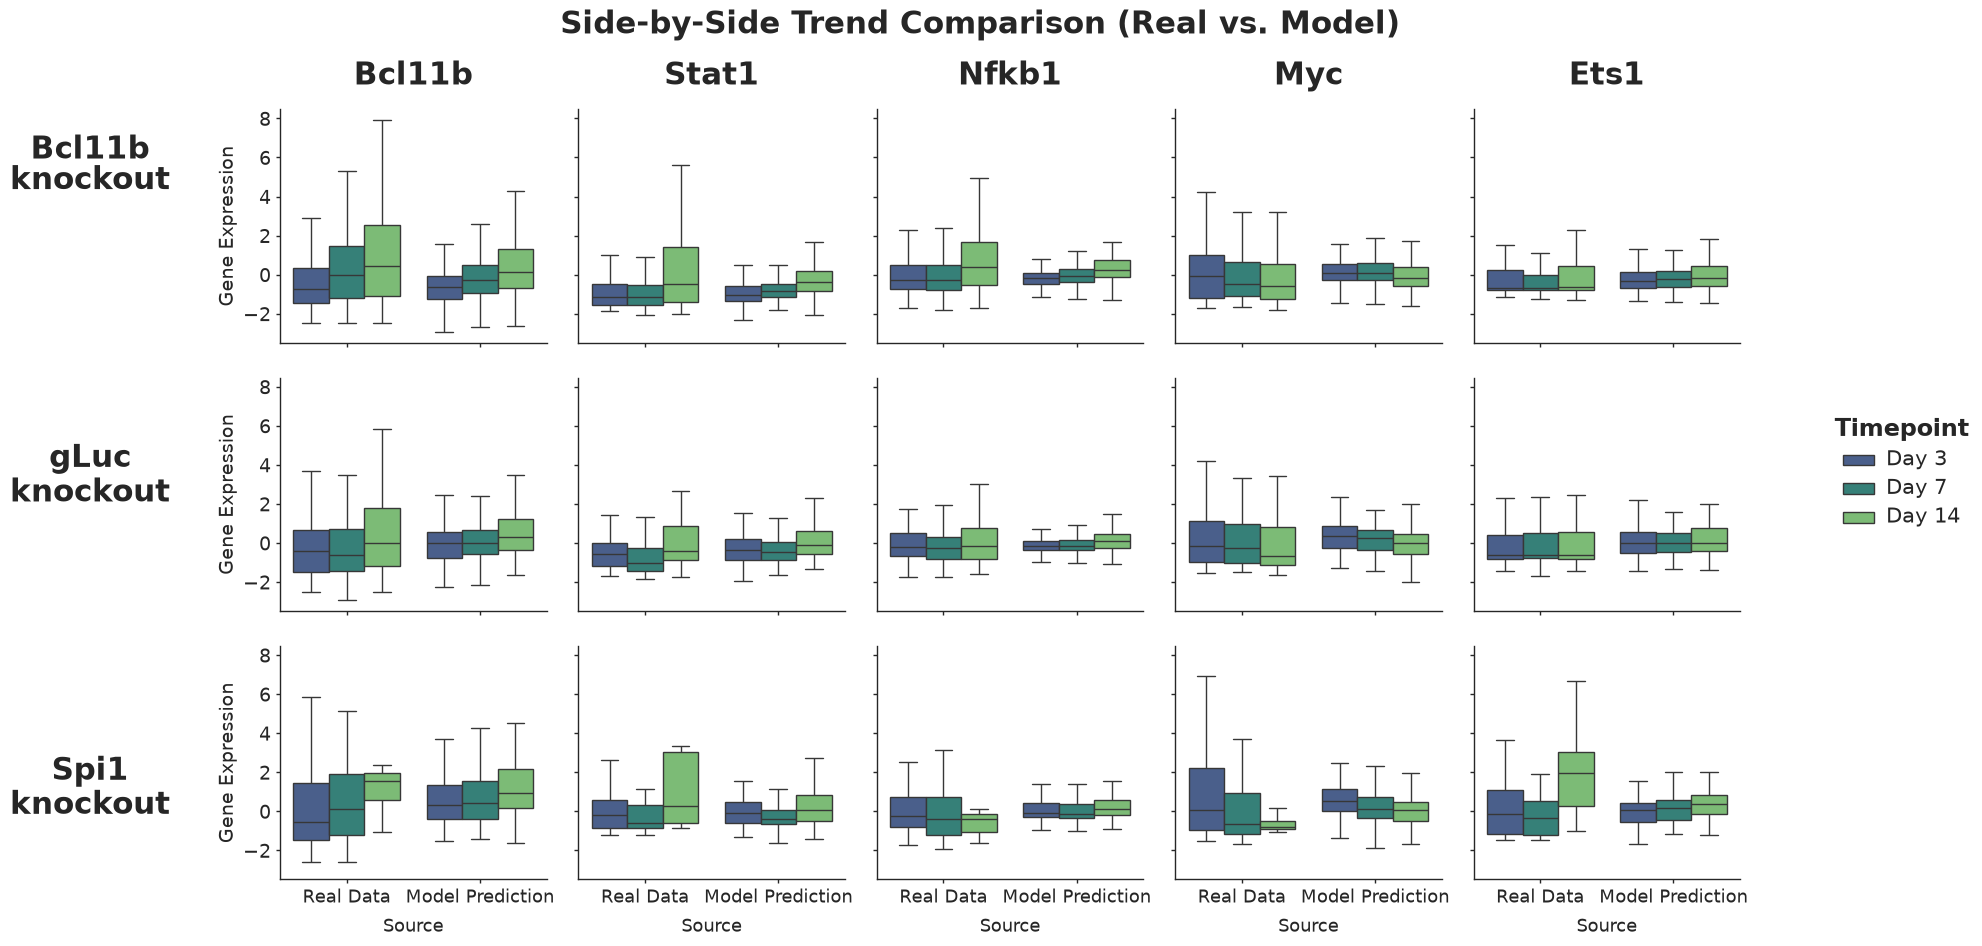

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. Prepare model prediction data
# =========================================================
n_steps = len(fore_ft)
step_each_day = (n_steps - 1) / 11

model_steps_to_extract = {
    "TP1": 0,
    "TP2": int(4 * step_each_day),
    "TP3": n_steps - 1
}

point_dic = {
    "TP1": "Day 3",
    "TP2": "Day 7",
    "TP3": "Day 14"
}

model_comparison_data = []

gene_indices = [
    adata.var_names.get_loc(g)
    for g in existing_genes
]

for condition, tensor in predicted_paths.items():

    # Convert torch tensor to NumPy if needed
    if hasattr(tensor, "detach"):
        tensor_np = tensor.detach().cpu().numpy()
    else:
        tensor_np = np.asarray(tensor)

    for timepoint, step in model_steps_to_extract.items():

        step_data = tensor_np[step, :, :][:, gene_indices]

        df = pd.DataFrame(
            step_data,
            columns=existing_genes
        )

        df["Timepoint"] = point_dic[timepoint]
        df["Condition"] = condition
        df["Source"] = "Model Prediction"

        model_comparison_data.append(df)


model_df = pd.concat(
    model_comparison_data,
    ignore_index=True
)


# =========================================================
# 2. Prepare real data
# =========================================================
real_data_subset = adata[
    adata.obs["CRISPRgene"].isin(conditions_to_analyze),
    existing_genes
]

real_df = real_data_subset.to_df().copy()

real_df["Timepoint"] = (
    real_data_subset.obs["timepoint"]
    .map(point_dic)
    .to_numpy()
)

real_df["Condition"] = (
    real_data_subset.obs["CRISPRgene"]
    .to_numpy()
)

real_df["Source"] = "Real Data"


# =========================================================
# 3. Combine and reshape
# =========================================================
comparison_df = pd.concat(
    [real_df, model_df],
    ignore_index=True
)

comparison_long_df = pd.melt(
    comparison_df,
    id_vars=[
        "Timepoint",
        "Condition",
        "Source"
    ],
    value_vars=existing_genes,
    var_name="Gene",
    value_name="Expression"
)


# =========================================================
# 4. Plot order and colors
# =========================================================
gene_order = list(existing_genes)

condition_order = [
    "Bcl11b",
    "gLuc",
    "Spi1"
]

timepoint_order = [
    "Day 3",
    "Day 7",
    "Day 14"
]

source_order = [
    "Real Data",
    "Model Prediction"
]

timepoint_palette = {
    "Day 3": "#3F5B96",
    "Day 7": "#2A8C82",
    "Day 14": "#73C66B"
}


# =========================================================
# 5. Plot
# =========================================================
sns.set_theme(
    style="ticks",
    context="notebook"
)

g = sns.catplot(
    data=comparison_long_df,
    x="Source",
    y="Expression",
    hue="Timepoint",
    col="Gene",
    row="Condition",
    kind="box",

    col_order=gene_order,
    row_order=condition_order,
    hue_order=timepoint_order,
    order=source_order,

    palette=timepoint_palette,
    showfliers=False,

    height=3.2,
    aspect=1.15,
    linewidth=1.0,

    legend_out=True
)


# =========================================================
# 6. Remove default facet titles
# =========================================================
g.set_titles("")

n_rows = len(condition_order)
n_cols = len(gene_order)


# =========================================================
# 7. Add gene names only above the first row
# =========================================================
for col_idx, gene in enumerate(gene_order):

    ax = g.axes[0, col_idx]

    ax.set_title(
        gene,
        fontsize=22,
        fontweight="bold",
        pad=18
    )


# =========================================================
# 8. Format axes
# =========================================================
for row_idx in range(n_rows):

    for col_idx in range(n_cols):

        ax = g.axes[row_idx, col_idx]

        # No background grid
        ax.grid(False)

        # Keep only left and bottom axes
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_linewidth(1.0)
        ax.spines["bottom"].set_linewidth(1.0)

        # General tick styling
        ax.tick_params(
            axis="y",
            labelsize=14,
            width=1.0,
            length=3
        )

        ax.tick_params(
            axis="x",
            labelsize=16,
            width=1.0,
            length=3
        )

        # Make Real Data / Model Prediction larger
        ax.set_xticks(
            np.arange(len(source_order))
        )

        ax.set_xticklabels(
            source_order,
            fontsize=13,
        )

        # Only show y-axis label in first column
        if col_idx == 0:
            ax.set_ylabel(
                "Gene Expression",
                fontsize=14,
            )
        else:
            ax.set_ylabel("")

        # Only show Source on the last row
        if row_idx == n_rows - 1:
            ax.set_xlabel(
                "Source",
                fontsize=13,
                labelpad=8
            )
        else:
            ax.set_xlabel("")


# =========================================================
# 9. Add bold knockout labels on the left
# =========================================================
row_labels = {
    "Bcl11b": "Bcl11b\nknockout",
    "gLuc": "gLuc\nknockout",
    "Spi1": "Spi1\nknockout"
}

for row_idx, condition in enumerate(condition_order):

    row_axes = g.axes[row_idx, :]

    # Calculate center of the complete row
    y0 = min(
        ax.get_position().y0
        for ax in row_axes
    )

    y1 = max(
        ax.get_position().y1
        for ax in row_axes
    )

    row_center_y = (y0 + y1) / 2

    g.fig.text(
        0.055,
        row_center_y,
        row_labels[condition],
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        linespacing=1.0
    )


# =========================================================
# 10. Legend formatting
# =========================================================
if g._legend is not None:

    g._legend.set_title("Timepoint")

    plt.setp(
        g._legend.get_title(),
        fontsize=17,
        fontweight="bold"
    )

    plt.setp(
        g._legend.get_texts(),
        fontsize=15
    )

    g._legend.set_frame_on(False)


# =========================================================
# 11. Overall title
# =========================================================
g.fig.suptitle(
    "Side-by-Side Trend Comparison (Real vs. Model)",
    y=0.98,
    fontsize=22,
    fontweight="bold"
)


# =========================================================
# 12. Figure size and spacing
# =========================================================
g.fig.set_size_inches(
    20,
    10
)

g.fig.subplots_adjust(
    left=0.15,
    right=0.88,
    top=0.88,
    bottom=0.11,
    wspace=0.12,
    hspace=0.15
)


# =========================================================
# 13. Save
# =========================================================
g.fig.savefig(
    "./CRISPR_results/Trend_Comparison.svg",
    format="svg",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()